In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("C:/Users/emmlo/Downloads/Retail_Sales_Intelligence/data/retail_sales_cleaned.csv")
df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39,Other,Central,Raipur,Groceries,Sugar,...,346.32,0.00,4043.14,289.18,56.04,Debit Card,3,True,Returned,7
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5,False,Delivered,2
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4,False,Delivered,5
3,ORD-02076,2022-05-07,CUST05587,Priya Reddy,29,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3,False,Delivered,4
4,ORD-00287,2020-07-05,CUST58035,Ritu Sharma,9,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4,False,Pending,4


In [2]:
#Total revennue and profit 
total_revenue = df['sales_amount'].sum()
total_profit= df['profit'].sum()

print(f"The total Revenue is {total_revenue}")
print(f"The total Profit is {total_profit}")

The total Revenue is 232498360.64000002
The total Profit is 43022201.4


In [3]:
#Total revenue and profit for each category
category_summary = df.groupby('product_category')[['sales_amount', 'profit']].sum().sort_values('sales_amount', ascending=False)
pd.options.display.float_format = '{:,.2f}'.format
print(category_summary)

                   sales_amount        profit
product_category                             
Electronics      138,282,263.40 16,661,828.14
Furniture         56,709,203.03 16,005,733.05
Sports            23,750,404.28  5,251,269.66
Clothing           6,695,932.40  2,360,197.15
Beauty             3,881,088.85  1,748,717.37
Books              2,310,491.16    924,872.64
Groceries            868,977.52     69,583.39


In [4]:
#Profit margin for each category
category_summary['profit_margin_pct'] = category_summary['profit']/category_summary['sales_amount']
print(category_summary.sort_values('profit_margin_pct', ascending=False))

                   sales_amount        profit  profit_margin_pct
product_category                                                
Beauty             3,881,088.85  1,748,717.37               0.45
Books              2,310,491.16    924,872.64               0.40
Clothing           6,695,932.40  2,360,197.15               0.35
Furniture         56,709,203.03 16,005,733.05               0.28
Sports            23,750,404.28  5,251,269.66               0.22
Electronics      138,282,263.40 16,661,828.14               0.12
Groceries            868,977.52     69,583.39               0.08


In [5]:
#Total revenue and profit for each region 
region_summary = df.groupby('region')[['sales_amount', 'profit']].sum().sort_values('sales_amount', ascending=False)
pd.options.display.float_format = '{:,.2f}'.format
print(region_summary)

         sales_amount       profit
region                            
South   53,039,014.22 9,753,183.57
West    47,962,618.16 8,862,052.09
East    47,771,900.79 8,474,537.36
North   45,332,775.15 8,547,486.86
Central 38,392,052.32 7,384,941.52


In [6]:
#Total revenue from different payment methods
payment_summary =  df.groupby('payment_method')[['sales_amount']].sum().sort_values('sales_amount', ascending=False)
print(payment_summary)

payment_summary = df['order_status'].value_counts()
print("\n Below is the number associated with different order statuses")
print(payment_summary)

                  sales_amount
payment_method                
Cash on Delivery 42,028,806.54
EMI              40,785,887.28
Debit Card       40,439,246.18
UPI              39,226,577.56
Credit Card      38,406,908.21
Net Banking      31,610,934.87

 Below is the number associated with different order statuses
order_status
Delivered    2725
Returned      610
Cancelled     346
Shipped       327
Pending       184
Name: count, dtype: int64


In [7]:
#Customer-level aggregation 
customer_summary = df.groupby('customer_id').agg(
    total_spent= ('sales_amount', 'sum'),
    num_of_orders= ('order_id', 'nunique'),
    avg_line_value= ('sales_amount', 'mean'),
    first_order= ('order_date', 'min'),
    last_order= ('order_date', 'max')
)

customer_summary.head()

,total_spent,num_of_orders,avg_line_value,first_order,last_order
customer_id,,,,,
CUST00013,222.90,1,222.90,2024-11-12,2024-11-12
CUST00024,"4,041.53",1,"4,041.53",2020-04-13,2020-04-13
CUST00053,"4,942.58",1,"4,942.58",2021-04-19,2021-04-19
CUST00081,"1,259.18",1,"1,259.18",2023-09-02,2023-09-02
CUST00084,"79,710.68",1,"79,710.68",2024-09-03,2024-09-03


In [8]:
#counting number of customers associated with number of orders
customer_summary['num_of_orders'].value_counts().sort_index()

num_of_orders
1    4019
2      85
3       1
Name: count, dtype: int64

In [9]:
#customer Type
customer_summary['customer_type'] = customer_summary['num_of_orders'].apply(
    lambda x: 'One-time' if x == 1 else 'Repeat'
)

#Customer type count
customer_summary['customer_type'].value_counts()

customer_type
One-time    4019
Repeat        86
Name: count, dtype: int64

In [10]:
#Sales trend by category 

df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.to_period('M')

category_trend = df.groupby(['order_month','product_category'])['sales_amount'].sum().reset_index()

category_trend.head(10)

,order_month,product_category,sales_amount
0,2020-01,Beauty,"86,281.74"
1,2020-01,Books,"21,280.34"
2,2020-01,Clothing,"164,938.44"
3,2020-01,Electronics,"1,582,187.35"
4,2020-01,Furniture,"1,257,868.67"
5,2020-01,Groceries,"7,238.40"
6,2020-01,Sports,"203,694.22"
7,2020-02,Beauty,"58,747.10"
8,2020-02,Books,"48,202.00"
9,2020-02,Clothing,"70,878.57"


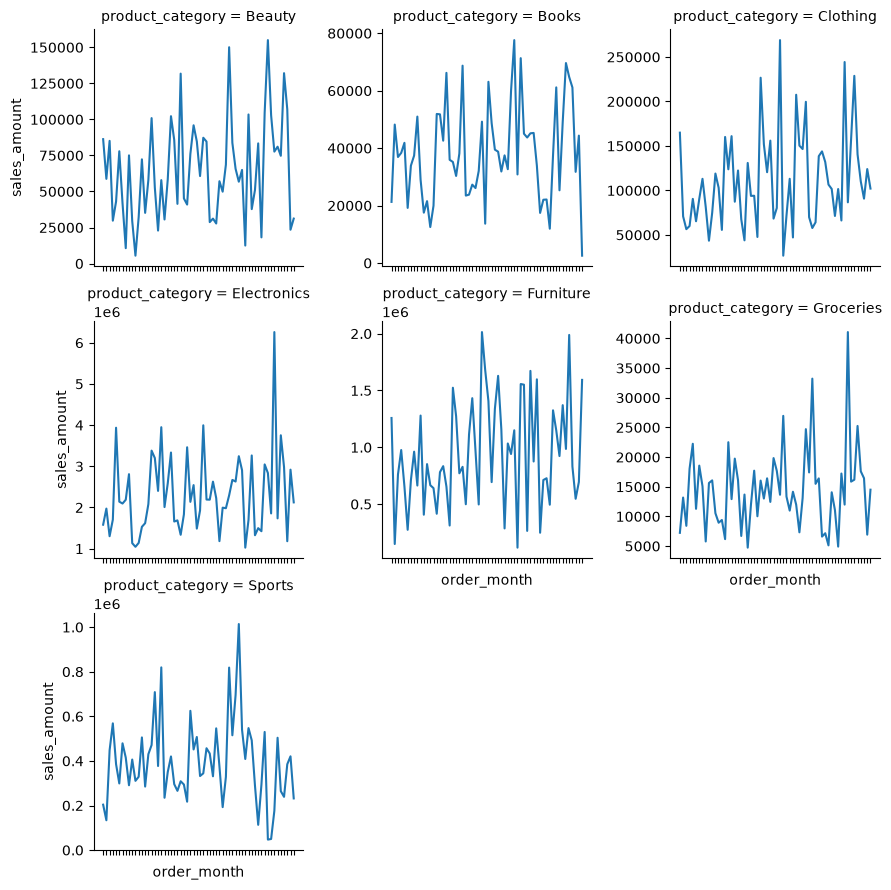

In [11]:
#Creating a plot with seaborn 

category_trend['order_month']= category_trend['order_month'].astype(str)

g = sns.FacetGrid(category_trend, col='product_category', col_wrap=3, sharey=False, height=3)
g.map_dataframe(sns.lineplot, x='order_month', y='sales_amount')
g.set_xticklabels(rotation=45)
plt.tight_layout()

plt.show()